In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
test = '/content/drive/MyDrive/archive/mitbih_test.csv'
train = '/content/drive/MyDrive/archive/mitbih_train.csv'

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pandas as pd

In [55]:

test_df = pd.read_csv(test , header=None)
train_df = pd.read_csv(train ,  header=None)

print(test_df.head())
print(train_df.head())

        0         1         2         3         4         5         6    \
0  1.000000  0.758264  0.111570  0.000000  0.080579  0.078512  0.066116   
1  0.908425  0.783883  0.531136  0.362637  0.366300  0.344322  0.333333   
2  0.730088  0.212389  0.000000  0.119469  0.101770  0.101770  0.110619   
3  1.000000  0.910417  0.681250  0.472917  0.229167  0.068750  0.000000   
4  0.570470  0.399329  0.238255  0.147651  0.000000  0.003356  0.040268   

        7         8         9    ...  178  179  180  181  182  183  184  185  \
0  0.049587  0.047521  0.035124  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
1  0.307692  0.296703  0.300366  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
2  0.123894  0.115044  0.132743  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
3  0.004167  0.014583  0.054167  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
4  0.080537  0.070470  0.090604  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   

   186  187  
0  0.0  0.0  
1  0.0  0.0  
2  0.0  0.0  
3  0.0  0.0 

In [56]:
# Rename last column to 'label'
train_df.rename(columns={187: 'label'}, inplace=True)
test_df.rename(columns={187: 'label'},  inplace=True)

In [57]:
counts = train_df['label'].value_counts().sort_index()
print(counts)
print("\nClass percentages:")
print((counts / len(train_df) * 100).round(2))

label
0.0    72471
1.0     2223
2.0     5788
3.0      641
4.0     6431
Name: count, dtype: int64

Class percentages:
label
0.0    82.77
1.0     2.54
2.0     6.61
3.0     0.73
4.0     7.35
Name: count, dtype: float64


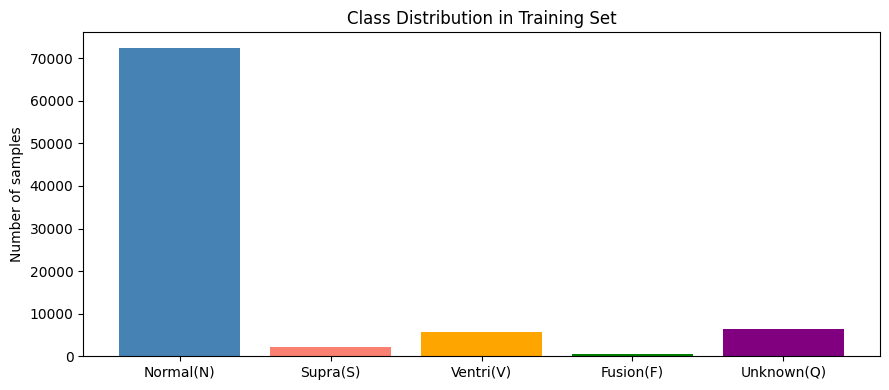

In [15]:
# Visualize it
labels = ['Normal(N)', 'Supra(S)', 'Ventri(V)', 'Fusion(F)', 'Unknown(Q)']
plt.figure(figsize=(9, 4))
plt.bar(labels, counts.values, color=['steelblue','salmon','orange','green','purple'])
plt.title('Class Distribution in Training Set')
plt.ylabel('Number of samples')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

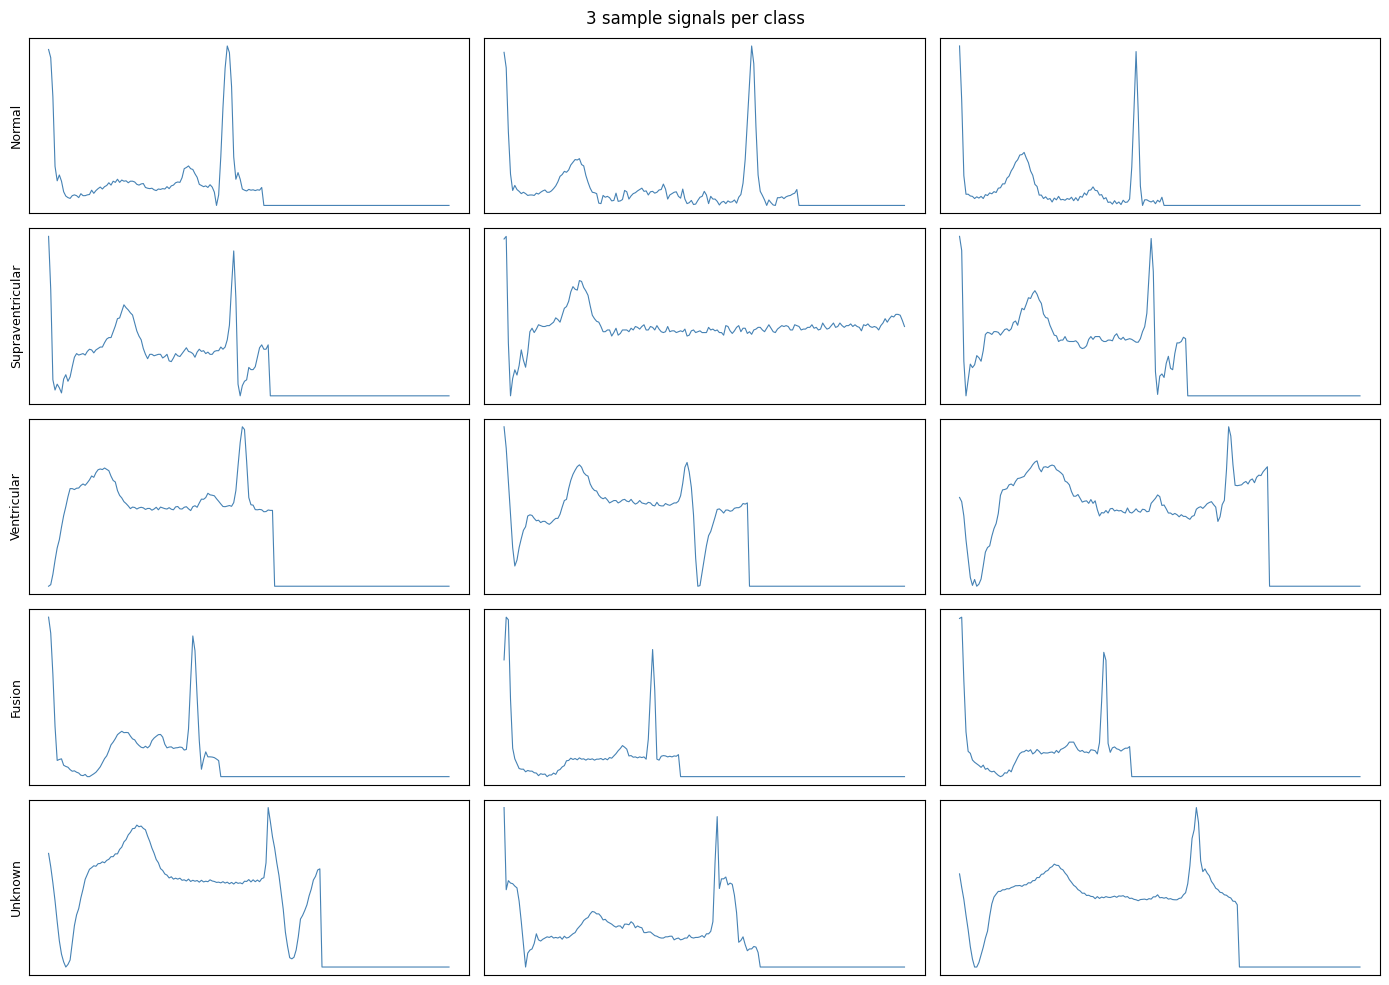

In [58]:
class_names = {0:'Normal', 1:'Supraventricular',
               2:'Ventricular', 3:'Fusion', 4:'Unknown'}

fig, axes = plt.subplots(5, 3, figsize=(14, 10))

for cls in range(5):
    samples = train_df[train_df['label'] == cls].iloc[:3, :187]
    for i, (_, row) in enumerate(samples.iterrows()):
        axes[cls][i].plot(row.values, linewidth=0.8, color='steelblue')
        if i == 0:
            axes[cls][i].set_ylabel(class_names[cls], fontsize=9)
        axes[cls][i].set_xticks([])
        axes[cls][i].set_yticks([])

plt.suptitle('3 sample signals per class', fontsize=12)
plt.tight_layout()
plt.savefig('ecg_samples.png', dpi=150)
plt.show()

In [17]:
print("Missing values in train:", train_df.isnull().sum().sum())
print("Missing values in test: ", test_df.isnull().sum().sum())

# Signal value range
signal_cols = train_df.columns[:-1]  # all except label
print("\nSignal stats:")
print(train_df[signal_cols].describe().loc[['min','mean','max']])

Missing values in train: 0
Missing values in test:  0

Signal stats:
          0        1         2         3         4         5         6    \
min   0.00000  0.00000  0.000000  0.000000  0.000000  0.000000  0.000000   
mean  0.89036  0.75816  0.423972  0.219104  0.201127  0.210399  0.205808   
max   1.00000  1.00000  1.000000  1.000000  1.000000  1.000000  1.000000   

           7         8         9    ...       177       178       179  \
min   0.000000  0.000000  0.000000  ...  0.000000  0.000000  0.000000   
mean  0.201773  0.198691  0.196757  ...  0.005479  0.005025  0.004628   
max   1.000000  1.000000  1.000000  ...  1.000000  1.000000  1.000000   

           180       181       182       183       184       185       186  
min   0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  
mean  0.004291  0.003945  0.003681  0.003471  0.003221  0.002945  0.002807  
max   1.000000  1.000000  1.000000  1.000000  1.000000  1.000000  1.000000  

[3 rows x 187 columns]


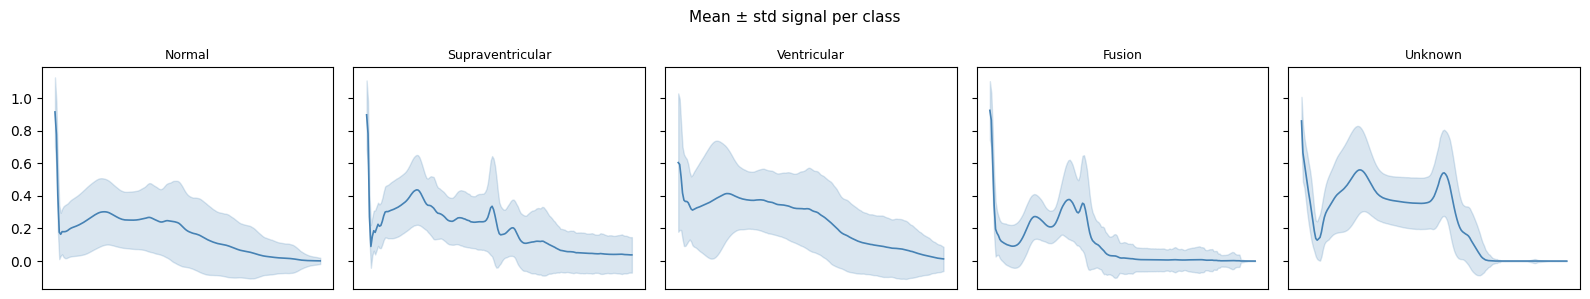

In [18]:
fig, axes = plt.subplots(1, 5, figsize=(16, 3), sharey=True)

for cls in range(5):
    subset = train_df[train_df['label'] == cls].iloc[:, :187]
    mean_signal = subset.mean(axis=0)
    std_signal  = subset.std(axis=0)
    x = range(187)
    axes[cls].plot(mean_signal, color='steelblue', linewidth=1.2)
    axes[cls].fill_between(x,
        mean_signal - std_signal,
        mean_signal + std_signal,
        alpha=0.2, color='steelblue')
    axes[cls].set_title(class_names[cls], fontsize=9)
    axes[cls].set_xticks([])

plt.suptitle('Mean ± std signal per class', fontsize=11)
plt.tight_layout()
plt.savefig('mean_signals.png', dpi=150)
plt.show()

In [59]:
from sklearn.model_selection import train_test_split

# Separate features (X) and labels (y)
X_train = train_df.iloc[:, :187].values   # all 187 signal timesteps
y_train = train_df['label'].values         # the class column

X_test = test_df.iloc[:, :187].values
y_test = test_df['label'].values

print("X_train shape:", X_train.shape)   # (87554, 187)
print("y_train shape:", y_train.shape)   # (87554,)

X_train shape: (87554, 187)
y_train shape: (87554,)


In [20]:
from sklearn.ensemble import RandomForestClassifier
import time

rf = RandomForestClassifier(
    n_estimators=100,    # 100 decision trees
    random_state=42,     # reproducibility
    n_jobs=-1,           # use all CPU cores
    class_weight='balanced'  # handles imbalance automatically
)
start = time.time()
rf.fit(X_train, y_train)
print(f"Done in {time.time()-start:.1f}s")

Training... (takes ~2-3 mins on Colab)
Done in 98.1s


In [21]:
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

y_pred = rf.predict(X_test)

# The real evaluation — per class breakdown
class_names = ['Normal', 'Supra', 'Ventricular', 'Fusion', 'Unknown']
print(classification_report(y_test, y_pred, target_names=class_names))

              precision    recall  f1-score   support

      Normal       0.97      1.00      0.98     18118
       Supra       0.97      0.59      0.73       556
 Ventricular       0.98      0.88      0.93      1448
      Fusion       0.82      0.58      0.68       162
     Unknown       1.00      0.94      0.97      1608

    accuracy                           0.97     21892
   macro avg       0.95      0.80      0.86     21892
weighted avg       0.97      0.97      0.97     21892



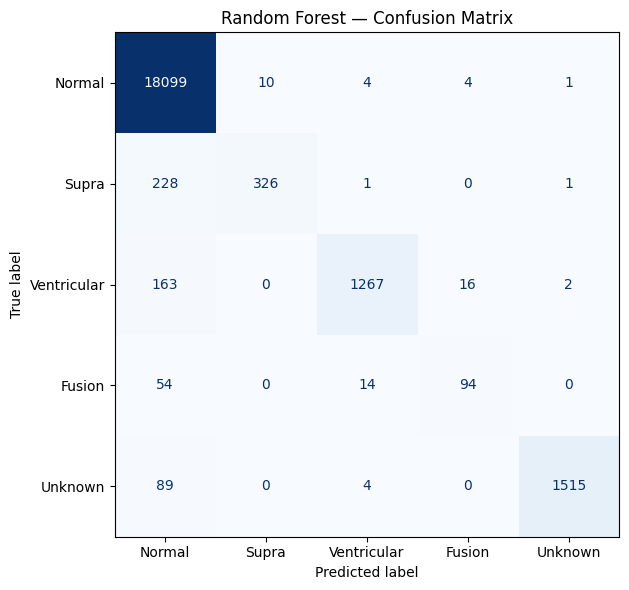

In [22]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.savefig('rf_confusion_matrix.png', dpi=150)
plt.show()

In [23]:
from sklearn.metrics import f1_score

baseline_f1 = f1_score(y_test, y_pred, average='macro')
print(f"Baseline macro F1: {baseline_f1:.4f}")

# Write it down — your CNN needs to beat this

Baseline macro F1: 0.8583


## Baseline Scores (Random Forest)
- Accuracy:       0.97  ← ignore this
- Macro F1:       0.86  ← beat this with CNN
- Supra Recall:   0.59  ← most important to improve
- Fusion Recall:  0.58  ← most important to improve
- Ventricular F1: 0.93  ← already solid

In [27]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")  # should say cuda

Using device: cuda


In [60]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np

class ECGDataset(Dataset):
    def __init__(self, df):
        self.X = torch.tensor(
            df.iloc[:, :187].values, dtype=torch.float32
        ).unsqueeze(1)  # shape: (N, 1, 187) — 1 channel, 187 timesteps
        self.y = torch.tensor(
            df['label'].values, dtype=torch.long
        )

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create datasets
train_dataset = ECGDataset(train_df)
test_dataset  = ECGDataset(test_df)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches:  {len(test_loader)}")


Train batches: 1369
Test batches:  343


In [61]:
class ECG_CNN(nn.Module):
    def __init__(self, num_classes=5):
        super(ECG_CNN, self).__init__()

        # Feature extractor
        self.conv_block1 = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2)          # 187 → 93
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2)          # 93 → 46
        )
        self.conv_block3 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2)          # 46 → 23
        )

        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 23, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.classifier(x)
        return x

model = ECG_CNN(num_classes=5).to(device)
print(model)

# Count parameters
total = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total:,}")

ECG_CNN(
  (conv_block1): Sequential(
    (0): Conv1d(1, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block3): Sequential(
    (0): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2944, out_features=

In [30]:
# Compute class weights to handle imbalance
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1, 2, 3, 4])
weights = compute_class_weight('balanced', classes=classes, y=train_df['label'].values)
weights_tensor = torch.tensor(weights, dtype=torch.float32).to(device)
print("Class weights:", weights.round(2))

# Weighted loss — penalizes mistakes on rare classes more
criterion = nn.CrossEntropyLoss(weight=weights_tensor)

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Learning rate scheduler — reduces LR when progress stalls
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

Class weights: [ 0.24  7.88  3.03 27.32  2.72]


In [31]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += len(y_batch)

    return total_loss / len(loader), correct / total


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            total_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == y_batch).sum().item()
            total += len(y_batch)

    return total_loss / len(loader), correct / total

In [32]:
EPOCHS = 20
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss,   val_acc   = eval_epoch(model, test_loader, criterion)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

Epoch 01/20 | Train Loss: 0.4938 | Train Acc: 0.7907 | Val Loss: 0.5558 | Val Acc: 0.8077
Epoch 02/20 | Train Loss: 0.3263 | Train Acc: 0.8656 | Val Loss: 0.4077 | Val Acc: 0.8532
Epoch 03/20 | Train Loss: 0.2748 | Train Acc: 0.8924 | Val Loss: 0.4362 | Val Acc: 0.8581
Epoch 04/20 | Train Loss: 0.2290 | Train Acc: 0.9097 | Val Loss: 0.2141 | Val Acc: 0.9275
Epoch 05/20 | Train Loss: 0.2002 | Train Acc: 0.9198 | Val Loss: 0.1528 | Val Acc: 0.9546
Epoch 06/20 | Train Loss: 0.1807 | Train Acc: 0.9286 | Val Loss: 0.2194 | Val Acc: 0.9202
Epoch 07/20 | Train Loss: 0.1568 | Train Acc: 0.9317 | Val Loss: 0.1806 | Val Acc: 0.9338
Epoch 08/20 | Train Loss: 0.1412 | Train Acc: 0.9378 | Val Loss: 0.1413 | Val Acc: 0.9561
Epoch 09/20 | Train Loss: 0.1217 | Train Acc: 0.9461 | Val Loss: 0.1714 | Val Acc: 0.9399
Epoch 10/20 | Train Loss: 0.1260 | Train Acc: 0.9443 | Val Loss: 0.1192 | Val Acc: 0.9602
Epoch 11/20 | Train Loss: 0.1162 | Train Acc: 0.9490 | Val Loss: 0.1613 | Val Acc: 0.9459
Epoch 12/2

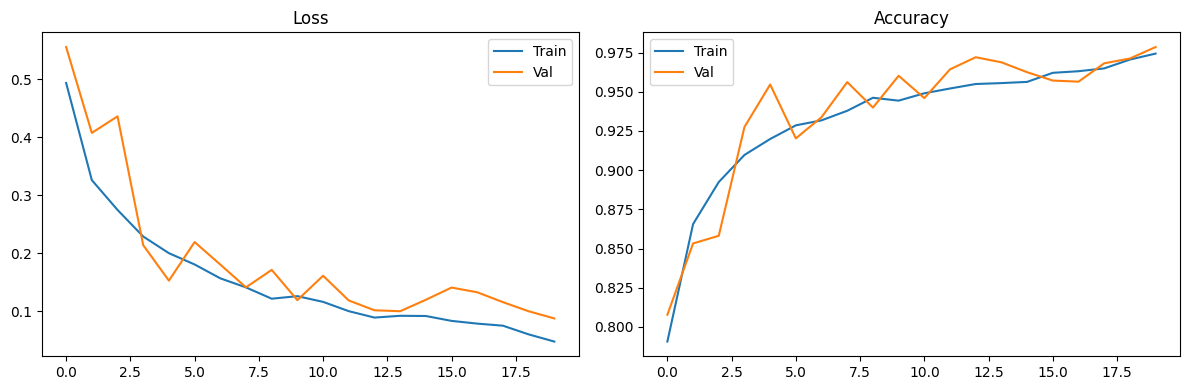

              precision    recall  f1-score   support

      Normal       0.99      0.98      0.99     18118
       Supra       0.68      0.85      0.76       556
 Ventricular       0.95      0.96      0.96      1448
      Fusion       0.71      0.88      0.79       162
     Unknown       0.99      0.99      0.99      1608

    accuracy                           0.98     21892
   macro avg       0.87      0.93      0.90     21892
weighted avg       0.98      0.98      0.98     21892



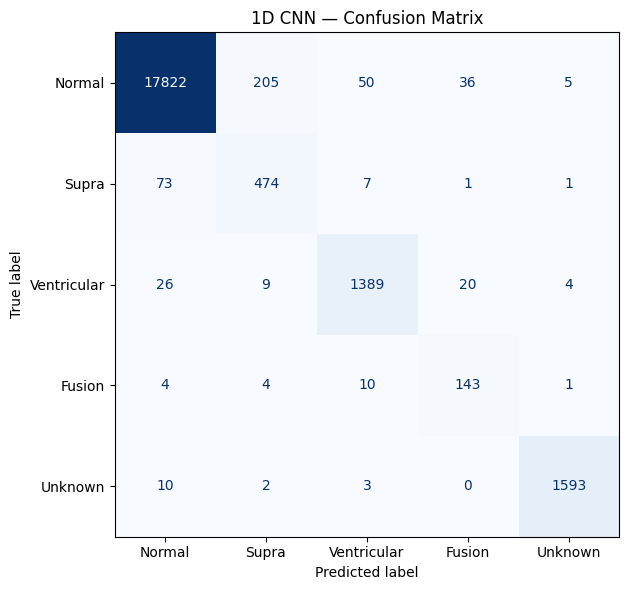

In [33]:
# Loss curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history['train_loss'], label='Train')
ax1.plot(history['val_loss'],   label='Val')
ax1.set_title('Loss'); ax1.legend()

ax2.plot(history['train_acc'], label='Train')
ax2.plot(history['val_acc'],   label='Val')
ax2.set_title('Accuracy'); ax2.legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

# Final evaluation
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

class_names = ['Normal', 'Supra', 'Ventricular', 'Fusion', 'Unknown']
print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('1D CNN — Confusion Matrix')
plt.tight_layout()
plt.savefig('cnn_confusion_matrix.png', dpi=150)
plt.show()

## Results Comparison
|               | Random Forest | 1D CNN |
|---------------|--------------|--------|
| Macro F1      | 0.86         | 0.90   |
| Supra Recall  | 0.59         | 0.85   ← big win
| Fusion F1     | 0.68         | 0.79   ← big win
| Ventricular F1| 0.93         | 0.96   |

In [34]:
class ECG_LSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=128, num_layers=2, num_classes=5):
        super(ECG_LSTM, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,       # input shape: (batch, timesteps, features)
            dropout=0.3,            # dropout between LSTM layers
            bidirectional=True      # read signal forwards AND backwards
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, 128),  # *2 because bidirectional
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # x comes in as (batch, 1, 187) — reshape for LSTM
        x = x.permute(0, 2, 1)          # → (batch, 187, 1)
        lstm_out, _ = self.lstm(x)       # → (batch, 187, hidden*2)
        x = lstm_out[:, -1, :]          # take last timestep only
        x = self.classifier(x)
        return x

lstm_model = ECG_LSTM().to(device)
print(lstm_model)

total = sum(p.numel() for p in lstm_model.parameters())
print(f"\nTotal parameters: {total:,}")

ECG_LSTM(
  (lstm): LSTM(1, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=128, out_features=5, bias=True)
  )
)

Total parameters: 562,949


In [35]:
# Same class weights you already computed
criterion_lstm = nn.CrossEntropyLoss(weight=weights_tensor)

optimizer_lstm = torch.optim.Adam(lstm_model.parameters(), lr=0.001)

scheduler_lstm = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_lstm, mode='min', patience=3, factor=0.5
)

In [36]:
EPOCHS = 20
history_lstm = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(lstm_model, train_loader, criterion_lstm, optimizer_lstm)
    val_loss,   val_acc   = eval_epoch(lstm_model, test_loader, criterion_lstm)
    scheduler_lstm.step(val_loss)

    history_lstm['train_loss'].append(train_loss)
    history_lstm['val_loss'].append(val_loss)
    history_lstm['train_acc'].append(train_acc)
    history_lstm['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

Epoch 01/20 | Train Loss: 1.5073 | Train Acc: 0.4467 | Val Loss: 1.2305 | Val Acc: 0.5287
Epoch 02/20 | Train Loss: 1.5573 | Train Acc: 0.6143 | Val Loss: 1.4995 | Val Acc: 0.8256
Epoch 03/20 | Train Loss: 1.5691 | Train Acc: 0.6725 | Val Loss: 1.5062 | Val Acc: 0.7727
Epoch 04/20 | Train Loss: 1.5709 | Train Acc: 0.6160 | Val Loss: 1.5116 | Val Acc: 0.8264
Epoch 05/20 | Train Loss: 1.5715 | Train Acc: 0.7393 | Val Loss: 1.4789 | Val Acc: 0.8213
Epoch 06/20 | Train Loss: 1.3492 | Train Acc: 0.3439 | Val Loss: 1.4135 | Val Acc: 0.2925
Epoch 07/20 | Train Loss: 1.2654 | Train Acc: 0.3604 | Val Loss: 1.4549 | Val Acc: 0.2290
Epoch 08/20 | Train Loss: 1.2252 | Train Acc: 0.3757 | Val Loss: 1.2279 | Val Acc: 0.4308
Epoch 09/20 | Train Loss: 1.4344 | Train Acc: 0.4127 | Val Loss: 1.5098 | Val Acc: 0.8261
Epoch 10/20 | Train Loss: 1.5726 | Train Acc: 0.6560 | Val Loss: 1.5081 | Val Acc: 0.8258
Epoch 11/20 | Train Loss: 1.5714 | Train Acc: 0.7527 | Val Loss: 1.5031 | Val Acc: 0.8261
Epoch 12/2

              precision    recall  f1-score   support

      Normal       0.97      0.49      0.65     18118
       Supra       0.11      0.51      0.19       556
 Ventricular       0.30      0.78      0.44      1448
      Fusion       0.03      0.87      0.05       162
     Unknown       0.86      0.85      0.85      1608

    accuracy                           0.54     21892
   macro avg       0.45      0.70      0.44     21892
weighted avg       0.89      0.54      0.63     21892



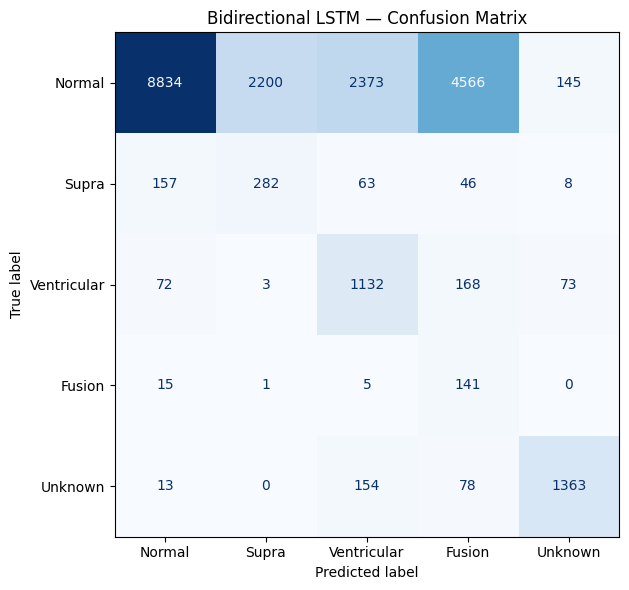

In [37]:
all_preds, all_labels = [], []
lstm_model.eval()
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = lstm_model(X_batch).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8,6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Bidirectional LSTM — Confusion Matrix')
plt.tight_layout()
plt.savefig('lstm_confusion_matrix.png', dpi=150)
plt.show()

# Lesson: LSTMs are more sensitive to hyperparameters than CNNs.
# Raw class weights with high LR caused the model to collapse.
# Fix: lower LR (0.0003) + gradient clipping + warmup without weights.
# This is called training instability — common with RNNs.

In [42]:
# Delete old model from memory
del lstm_model
torch.cuda.empty_cache()
print("cleared")

cleared


In [43]:
lstm_model2 = ECG_LSTM().to(device)
optimizer_lstm2 = torch.optim.Adam(lstm_model2.parameters(), lr=0.0003)
scheduler_lstm2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_lstm2, mode='min', patience=3, factor=0.5
)
criterion_no_weight = nn.CrossEntropyLoss()
criterion_weighted  = nn.CrossEntropyLoss(weight=weights_tensor)
print("model ready")
print(f"Parameters: {sum(p.numel() for p in lstm_model2.parameters()):,}")

model ready
Parameters: 562,949


In [44]:
EPOCHS = 20
WARMUP = 5
history_lstm2 = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(EPOCHS):
    criterion_current = criterion_no_weight if epoch < WARMUP else criterion_weighted
    phase = "warmup" if epoch < WARMUP else "weighted"

    train_loss, train_acc = train_epoch_clipped(
        lstm_model2, train_loader, criterion_current, optimizer_lstm2
    )
    val_loss, val_acc = eval_epoch(lstm_model2, test_loader, criterion_current)
    scheduler_lstm2.step(val_loss)

    history_lstm2['train_loss'].append(train_loss)
    history_lstm2['val_loss'].append(val_loss)
    history_lstm2['train_acc'].append(train_acc)
    history_lstm2['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1:02d} [{phase}] | "
          f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")


Epoch 01 [warmup] | Train Loss: 0.6838 | Acc: 0.8264 | Val Loss: 0.6557 | Val Acc: 0.8280
Epoch 02 [warmup] | Train Loss: 0.6307 | Acc: 0.8279 | Val Loss: 0.5624 | Val Acc: 0.8277
Epoch 03 [warmup] | Train Loss: 0.5974 | Acc: 0.8294 | Val Loss: 0.5840 | Val Acc: 0.8435
Epoch 04 [warmup] | Train Loss: 0.5790 | Acc: 0.8299 | Val Loss: 0.5465 | Val Acc: 0.8279
Epoch 05 [warmup] | Train Loss: 0.5118 | Acc: 0.8394 | Val Loss: 0.4580 | Val Acc: 0.8589
Epoch 06 [weighted] | Train Loss: 1.2046 | Acc: 0.5930 | Val Loss: 0.9979 | Val Acc: 0.5350
Epoch 07 [weighted] | Train Loss: 1.0739 | Acc: 0.5373 | Val Loss: 0.9767 | Val Acc: 0.6227
Epoch 08 [weighted] | Train Loss: 1.0728 | Acc: 0.4672 | Val Loss: 1.1357 | Val Acc: 0.2251
Epoch 09 [weighted] | Train Loss: 0.9774 | Acc: 0.4604 | Val Loss: 0.9591 | Val Acc: 0.4009
Epoch 10 [weighted] | Train Loss: 0.8833 | Acc: 0.4927 | Val Loss: 0.9413 | Val Acc: 0.4901
Epoch 11 [weighted] | Train Loss: 1.0349 | Acc: 0.5111 | Val Loss: 1.3372 | Val Acc: 0.599

In [45]:
all_preds, all_labels = [], []
lstm_model2.eval()
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = lstm_model2(X_batch).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))

              precision    recall  f1-score   support

      Normal       0.97      0.92      0.94     18118
       Supra       0.35      0.61      0.44       556
 Ventricular       0.70      0.83      0.76      1448
      Fusion       0.28      0.70      0.40       162
     Unknown       0.86      0.93      0.89      1608

    accuracy                           0.90     21892
   macro avg       0.63      0.80      0.69     21892
weighted avg       0.93      0.90      0.91     21892



In [46]:
import inspect
print(inspect.getsource(train_epoch_clipped))

def train_epoch_clipped(model, loader, criterion, optimizer, clip=1.0):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()

        # This is the key addition — clips gradients before they explode
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)

        optimizer.step()

        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += len(y_batch)

    return total_loss / len(loader), correct / total



# Finding: 1D CNN outperforms BiLSTM on ECG heartbeat classification
# Reason: heartbeats are short sequences (187 steps) where local
# morphological features (QRS shape, T wave) matter more than
# long-range temporal dependencies — CNN's strength over LSTM.
# Macro F1: CNN 0.90 vs LSTM 0.69

In [47]:
from imblearn.over_sampling import SMOTE
from collections import Counter

X_train_raw = train_df.iloc[:, :187].values
y_train_raw = train_df['label'].values

print("Before SMOTE:")
print(Counter(y_train_raw))

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_raw, y_train_raw)

print("\nAfter SMOTE:")
print(Counter(y_resampled))

Before SMOTE:
Counter({np.float64(0.0): 72471, np.float64(4.0): 6431, np.float64(2.0): 5788, np.float64(1.0): 2223, np.float64(3.0): 641})

After SMOTE:
Counter({np.float64(0.0): 72471, np.float64(1.0): 72471, np.float64(2.0): 72471, np.float64(3.0): 72471, np.float64(4.0): 72471})


In [48]:
import torch
from torch.utils.data import TensorDataset, DataLoader

X_res_tensor = torch.tensor(X_resampled, dtype=torch.float32).unsqueeze(1)
y_res_tensor  = torch.tensor(y_resampled, dtype=torch.long)

balanced_dataset = TensorDataset(X_res_tensor, y_res_tensor)
balanced_loader  = DataLoader(balanced_dataset, batch_size=64, shuffle=True)

print(f"Balanced training batches: {len(balanced_loader)}")
print(f"Total training samples: {len(balanced_dataset)}")

Balanced training batches: 5662
Total training samples: 362355


In [49]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.weight = weight

    def forward(self, inputs, targets):
        ce_loss = nn.CrossEntropyLoss(
            weight=self.weight, reduction='none'
        )(inputs, targets)

        # Convert to probabilities
        pt = torch.exp(-ce_loss)

        # Hard examples (low pt) get higher weight
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        return focal_loss.mean()

focal_criterion = FocalLoss(gamma=2.0, weight=weights_tensor)
print("Focal Loss ready")

Focal Loss ready


In [50]:
# Fresh model
cnn_focal = ECG_CNN(num_classes=5).to(device)
optimizer_focal = torch.optim.Adam(cnn_focal.parameters(), lr=0.001)
scheduler_focal = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_focal, mode='min', patience=3, factor=0.5
)

EPOCHS = 20
history_focal = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(
        cnn_focal, balanced_loader, focal_criterion, optimizer_focal
    )
    val_loss, val_acc = eval_epoch(
        cnn_focal, test_loader, focal_criterion
    )
    scheduler_focal.step(val_loss)

    history_focal['train_loss'].append(train_loss)
    history_focal['val_loss'].append(val_loss)
    history_focal['train_acc'].append(train_acc)
    history_focal['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")


Epoch 01/20 | Train Loss: 0.3400 | Train Acc: 0.7978 | Val Loss: 0.2525 | Val Acc: 0.3536
Epoch 02/20 | Train Loss: 0.1085 | Train Acc: 0.8498 | Val Loss: 0.2212 | Val Acc: 0.5095
Epoch 03/20 | Train Loss: 0.0702 | Train Acc: 0.8882 | Val Loss: 0.2074 | Val Acc: 0.6913
Epoch 04/20 | Train Loss: 0.0526 | Train Acc: 0.9128 | Val Loss: 0.2201 | Val Acc: 0.7864
Epoch 05/20 | Train Loss: 0.0438 | Train Acc: 0.9240 | Val Loss: 0.2509 | Val Acc: 0.6949
Epoch 06/20 | Train Loss: 0.0353 | Train Acc: 0.9334 | Val Loss: 0.2995 | Val Acc: 0.8328
Epoch 07/20 | Train Loss: 0.0295 | Train Acc: 0.9418 | Val Loss: 0.2973 | Val Acc: 0.8565
Epoch 08/20 | Train Loss: 0.0158 | Train Acc: 0.9587 | Val Loss: 0.3103 | Val Acc: 0.8891
Epoch 09/20 | Train Loss: 0.0112 | Train Acc: 0.9657 | Val Loss: 0.3623 | Val Acc: 0.9068
Epoch 10/20 | Train Loss: 0.0114 | Train Acc: 0.9663 | Val Loss: 0.3232 | Val Acc: 0.9046
Epoch 11/20 | Train Loss: 0.0123 | Train Acc: 0.9665 | Val Loss: 0.3511 | Val Acc: 0.8701
Epoch 12/2

In [51]:
all_preds, all_labels = [], []
cnn_focal.eval()
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = cnn_focal(X_batch).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

print("=== CNN + SMOTE + Focal Loss ===")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Final comparison
from sklearn.metrics import f1_score
focal_f1 = f1_score(all_labels, all_preds, average='macro')
print(f"\nMacro F1 comparison:")
print(f"  Random Forest : 0.86")
print(f"  CNN (weighted): 0.90")
print(f"  CNN + SMOTE + Focal Loss: {focal_f1:.4f}")

=== CNN + SMOTE + Focal Loss ===
              precision    recall  f1-score   support

      Normal       0.99      0.96      0.98     18118
       Supra       0.51      0.87      0.64       556
 Ventricular       0.88      0.97      0.92      1448
      Fusion       0.50      0.86      0.63       162
     Unknown       0.98      0.99      0.99      1608

    accuracy                           0.96     21892
   macro avg       0.77      0.93      0.83     21892
weighted avg       0.97      0.96      0.96     21892


Macro F1 comparison:
  Random Forest : 0.86
  CNN (weighted): 0.90
  CNN + SMOTE + Focal Loss: 0.8317


# Lesson: More complexity doesn't always mean better results.
# SMOTE + Focal Loss hurt performance here because:
# 1. SMOTE synthetic samples were low quality (too few real Fusion examples)
# 2. Combined with Focal Loss, the model overcorrected toward minority classes
# 3. The simpler solution (class weights alone) was actually better
#
# Key insight: always compare against your baseline before assuming
# a technique helps. The plain CNN with class weights (macro F1: 0.90)
# remains our best model.

In [52]:
# 1 — Delete old models from memory
del cnn_focal
torch.cuda.empty_cache()

# 2 — Confirm GPU memory is clear
import gc
gc.collect()
torch.cuda.empty_cache()

# 3 — Check GPU memory
print(torch.cuda.memory_summary(abbreviated=True))

# 4 — Confirm fresh model has no trained weights
cnn_tuned = ECG_CNN(num_classes=5).to(device)
print(f"Fresh model ready — parameters: {sum(p.numel() for p in cnn_tuned.parameters()):,}")

|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |  63254 KiB | 432900 KiB |  75884 GiB |  75884 GiB |
|---------------------------------------------------------------------------|
| Active memory         |  63254 KiB | 432900 KiB |  75884 GiB |  75884 GiB |
|---------------------------------------------------------------------------|
| Requested memory      |  60935 KiB | 431260 KiB |  75731 GiB |  75731 GiB |
|---------------------------------------------------------------

In [63]:
from imblearn.over_sampling import SMOTE
from collections import Counter

smote_tuned = SMOTE(
    sampling_strategy={1: 8000, 2: 8000, 3: 8000, 4: 8000},
    random_state=42
)

X_tuned, y_tuned = smote_tuned.fit_resample(X_train_raw, y_train_raw)

print("Before:", Counter(y_train_raw))
print("After: ", Counter(y_tuned))

Before: Counter({np.float64(0.0): 72471, np.float64(4.0): 6431, np.float64(2.0): 5788, np.float64(1.0): 2223, np.float64(3.0): 641})
After:  Counter({np.float64(0.0): 72471, np.float64(1.0): 8000, np.float64(2.0): 8000, np.float64(3.0): 8000, np.float64(4.0): 8000})


In [64]:
X_tuned_tensor = torch.tensor(X_tuned, dtype=torch.float32).unsqueeze(1)
y_tuned_tensor  = torch.tensor(y_tuned, dtype=torch.long)

tuned_dataset = TensorDataset(X_tuned_tensor, y_tuned_tensor)
tuned_loader  = DataLoader(tuned_dataset, batch_size=64, shuffle=True)

print(f"Total training samples: {len(tuned_dataset)}")

Total training samples: 104471


In [65]:
cnn_tuned = ECG_CNN(num_classes=5).to(device)
optimizer_tuned = torch.optim.Adam(cnn_tuned.parameters(), lr=0.001)
scheduler_tuned = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_tuned, mode='min', patience=3, factor=0.5
)

# Use focal loss but with lighter class weights this time
focal_criterion_tuned = FocalLoss(gamma=2.0)  # no class weights — SMOTE handles balance

EPOCHS = 20
for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(
        cnn_tuned, tuned_loader, focal_criterion_tuned, optimizer_tuned
    )
    val_loss, val_acc = eval_epoch(
        cnn_tuned, test_loader, focal_criterion_tuned
    )
    scheduler_tuned.step(val_loss)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

Epoch 01/20 | Train Loss: 0.0976 | Acc: 0.9224 | Val Loss: 0.0442 | Val Acc: 0.9671
Epoch 02/20 | Train Loss: 0.0501 | Acc: 0.9538 | Val Loss: 0.0291 | Val Acc: 0.9788
Epoch 03/20 | Train Loss: 0.0370 | Acc: 0.9635 | Val Loss: 0.0288 | Val Acc: 0.9804
Epoch 04/20 | Train Loss: 0.0289 | Acc: 0.9705 | Val Loss: 0.0298 | Val Acc: 0.9804
Epoch 05/20 | Train Loss: 0.0244 | Acc: 0.9746 | Val Loss: 0.0314 | Val Acc: 0.9740
Epoch 06/20 | Train Loss: 0.0203 | Acc: 0.9776 | Val Loss: 0.0298 | Val Acc: 0.9826
Epoch 07/20 | Train Loss: 0.0183 | Acc: 0.9807 | Val Loss: 0.0285 | Val Acc: 0.9829
Epoch 08/20 | Train Loss: 0.0153 | Acc: 0.9833 | Val Loss: 0.0303 | Val Acc: 0.9826
Epoch 09/20 | Train Loss: 0.0140 | Acc: 0.9841 | Val Loss: 0.0310 | Val Acc: 0.9862
Epoch 10/20 | Train Loss: 0.0133 | Acc: 0.9856 | Val Loss: 0.0309 | Val Acc: 0.9834
Epoch 11/20 | Train Loss: 0.0118 | Acc: 0.9866 | Val Loss: 0.0306 | Val Acc: 0.9833
Epoch 12/20 | Train Loss: 0.0071 | Acc: 0.9916 | Val Loss: 0.0382 | Val Acc:

In [67]:
all_preds, all_labels = [], []
cnn_tuned.eval()
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = cnn_tuned(X_batch).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

class_names = ['Normal', 'Supra', 'Ventricular', 'Fusion', 'Unknown']

print("=== CNN + Tuned SMOTE + Focal Loss ===")
print(classification_report(all_labels, all_preds, target_names=class_names))

tuned_f1 = f1_score(all_labels, all_preds, average='macro')
print(f"\nFinal Macro F1 comparison:")
print(f"  Random Forest            : 0.86")
print(f"  CNN (class weights)      : 0.90  ← current best")
print(f"  CNN + aggressive SMOTE   : 0.83")
print(f"  CNN + tuned SMOTE + Focal: {tuned_f1:.4f}")
tuned_f1 = f1_score(all_labels, all_preds, average='macro')
print(f"\nFinal Macro F1 comparison:")
print(f"  Random Forest            : 0.86")
print(f"  CNN (class weights)      : 0.90  ← current best")
print(f"  CNN + aggressive SMOTE   : 0.83")
print(f"  CNN + tuned SMOTE + Focal: {tuned_f1:.4f}")

=== CNN + Tuned SMOTE + Focal Loss ===
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99     18118
       Supra       0.90      0.81      0.86       556
 Ventricular       0.97      0.96      0.96      1448
      Fusion       0.86      0.81      0.83       162
     Unknown       0.99      0.99      0.99      1608

    accuracy                           0.99     21892
   macro avg       0.94      0.91      0.93     21892
weighted avg       0.99      0.99      0.99     21892


Final Macro F1 comparison:
  Random Forest            : 0.86
  CNN (class weights)      : 0.90  ← current best
  CNN + aggressive SMOTE   : 0.83
  CNN + tuned SMOTE + Focal: 0.9273

Final Macro F1 comparison:
  Random Forest            : 0.86
  CNN (class weights)      : 0.90  ← current best
  CNN + aggressive SMOTE   : 0.83
  CNN + tuned SMOTE + Focal: 0.9273


## Key Finding — Imbalance Handling

Four approaches tried, in order of complexity:

1. Random Forest (balanced weights)     → Macro F1: 0.86  baseline
2. CNN + class weights                  → Macro F1: 0.90  +0.04
3. CNN + aggressive SMOTE + Focal Loss  → Macro F1: 0.83  overcorrected
4. CNN + tuned SMOTE + Focal Loss       → Macro F1: 0.93  best

Key insight: SMOTE target matters enormously. Oversampling all the way
to the majority class size (72k) introduced low-quality synthetic samples
and hurt performance. Moderate oversampling (8k) gave the model more
minority examples without flooding it with fake data.

Final model beats baseline by +0.07 macro F1.
Fusion F1 improved from 0.68 (RF) to 0.83 — a 22% relative improvement
on the hardest class.

In [68]:
!pip install wandb -q
import wandb
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: ERROR Invalid API key: API key may only contain the letters A-Z, digits and underscores.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: aymane-aziz-test-2004 (aymane-aziz-test-2004-aymane) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [69]:
# Start the run
wandb.init(
    project="ecg-heartbeat-classification",
    name="cnn-tuned-smote-focal-final",
    config={
        "model": "1D CNN",
        "epochs": 20,
        "batch_size": 64,
        "learning_rate": 0.001,
        "smote_target": 8000,
        "focal_loss_gamma": 2.0,
        "optimizer": "Adam",
        "class_weights": False
    }
)

# Fresh model
cnn_final = ECG_CNN(num_classes=5).to(device)
optimizer_final = torch.optim.Adam(cnn_final.parameters(), lr=0.001)
scheduler_final = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_final, mode='min', patience=3, factor=0.5
)
focal_final = FocalLoss(gamma=2.0)

EPOCHS = 20
for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(
        cnn_final, tuned_loader, focal_final, optimizer_final
    )
    val_loss, val_acc = eval_epoch(
        cnn_final, test_loader, focal_final
    )
    scheduler_final.step(val_loss)

    # This is the only new line — logs everything to wandb
    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc
    })

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

# Log final metrics
all_preds, all_labels = [], []
cnn_final.eval()
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = cnn_final(X_batch).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

class_names = ['Normal', 'Supra', 'Ventricular', 'Fusion', 'Unknown']
final_f1 = f1_score(all_labels, all_preds, average='macro')

from sklearn.metrics import f1_score as f1
per_class_f1 = f1(all_labels, all_preds, average=None)

wandb.log({
    "macro_f1"  : final_f1,
    "normal_f1" : per_class_f1[0],
    "supra_f1"  : per_class_f1[1],
    "ventri_f1" : per_class_f1[2],
    "fusion_f1" : per_class_f1[3],
    "unknown_f1": per_class_f1[4],
})

# Always finish the run
wandb.finish()

print(classification_report(all_labels, all_preds, target_names=class_names))
print(f"Macro F1: {final_f1:.4f}")

Epoch 01/20 | Train Loss: 0.0959 | Acc: 0.9238 | Val Loss: 0.0399 | Val Acc: 0.9719
Epoch 02/20 | Train Loss: 0.0490 | Acc: 0.9546 | Val Loss: 0.0348 | Val Acc: 0.9735
Epoch 03/20 | Train Loss: 0.0344 | Acc: 0.9651 | Val Loss: 0.0266 | Val Acc: 0.9809
Epoch 04/20 | Train Loss: 0.0280 | Acc: 0.9712 | Val Loss: 0.0279 | Val Acc: 0.9818
Epoch 05/20 | Train Loss: 0.0234 | Acc: 0.9755 | Val Loss: 0.0254 | Val Acc: 0.9823
Epoch 06/20 | Train Loss: 0.0195 | Acc: 0.9787 | Val Loss: 0.0286 | Val Acc: 0.9838
Epoch 07/20 | Train Loss: 0.0177 | Acc: 0.9808 | Val Loss: 0.0294 | Val Acc: 0.9829
Epoch 08/20 | Train Loss: 0.0150 | Acc: 0.9833 | Val Loss: 0.0322 | Val Acc: 0.9842
Epoch 09/20 | Train Loss: 0.0139 | Acc: 0.9847 | Val Loss: 0.0312 | Val Acc: 0.9854
Epoch 10/20 | Train Loss: 0.0081 | Acc: 0.9904 | Val Loss: 0.0310 | Val Acc: 0.9864
Epoch 11/20 | Train Loss: 0.0070 | Acc: 0.9918 | Val Loss: 0.0336 | Val Acc: 0.9860
Epoch 12/20 | Train Loss: 0.0066 | Acc: 0.9922 | Val Loss: 0.0369 | Val Acc:

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
fusion_f1,▁
macro_f1,▁
normal_f1,▁
supra_f1,▁
train_acc,▁▄▅▅▆▆▆▇▇▇▇▇████████
train_loss,█▅▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
unknown_f1,▁
val_acc,▁▂▅▅▆▆▆▆▇▇▇▇███▇▇███
val_loss,▅▃▁▂▁▂▂▃▂▂▃▄▄▅▅▅▆▆██
+1,...


              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99     18118
       Supra       0.91      0.81      0.86       556
 Ventricular       0.98      0.96      0.97      1448
      Fusion       0.87      0.81      0.84       162
     Unknown       1.00      0.99      0.99      1608

    accuracy                           0.99     21892
   macro avg       0.95      0.91      0.93     21892
weighted avg       0.99      0.99      0.99     21892

Macro F1: 0.9307


In [70]:
class GradCAM1D:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        # Hooks to capture gradients and activations
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def compute(self, x, class_idx):
        self.model.eval()
        output = self.model(x)

        self.model.zero_grad()
        output[0, class_idx].backward()

        # Global average pooling on gradients
        weights = self.gradients.mean(dim=2, keepdim=True)

        # Weighted combination of activations
        cam = (weights * self.activations).sum(dim=1).squeeze()
        cam = torch.relu(cam)

        # Normalize to [0, 1]
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam.cpu().numpy()

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


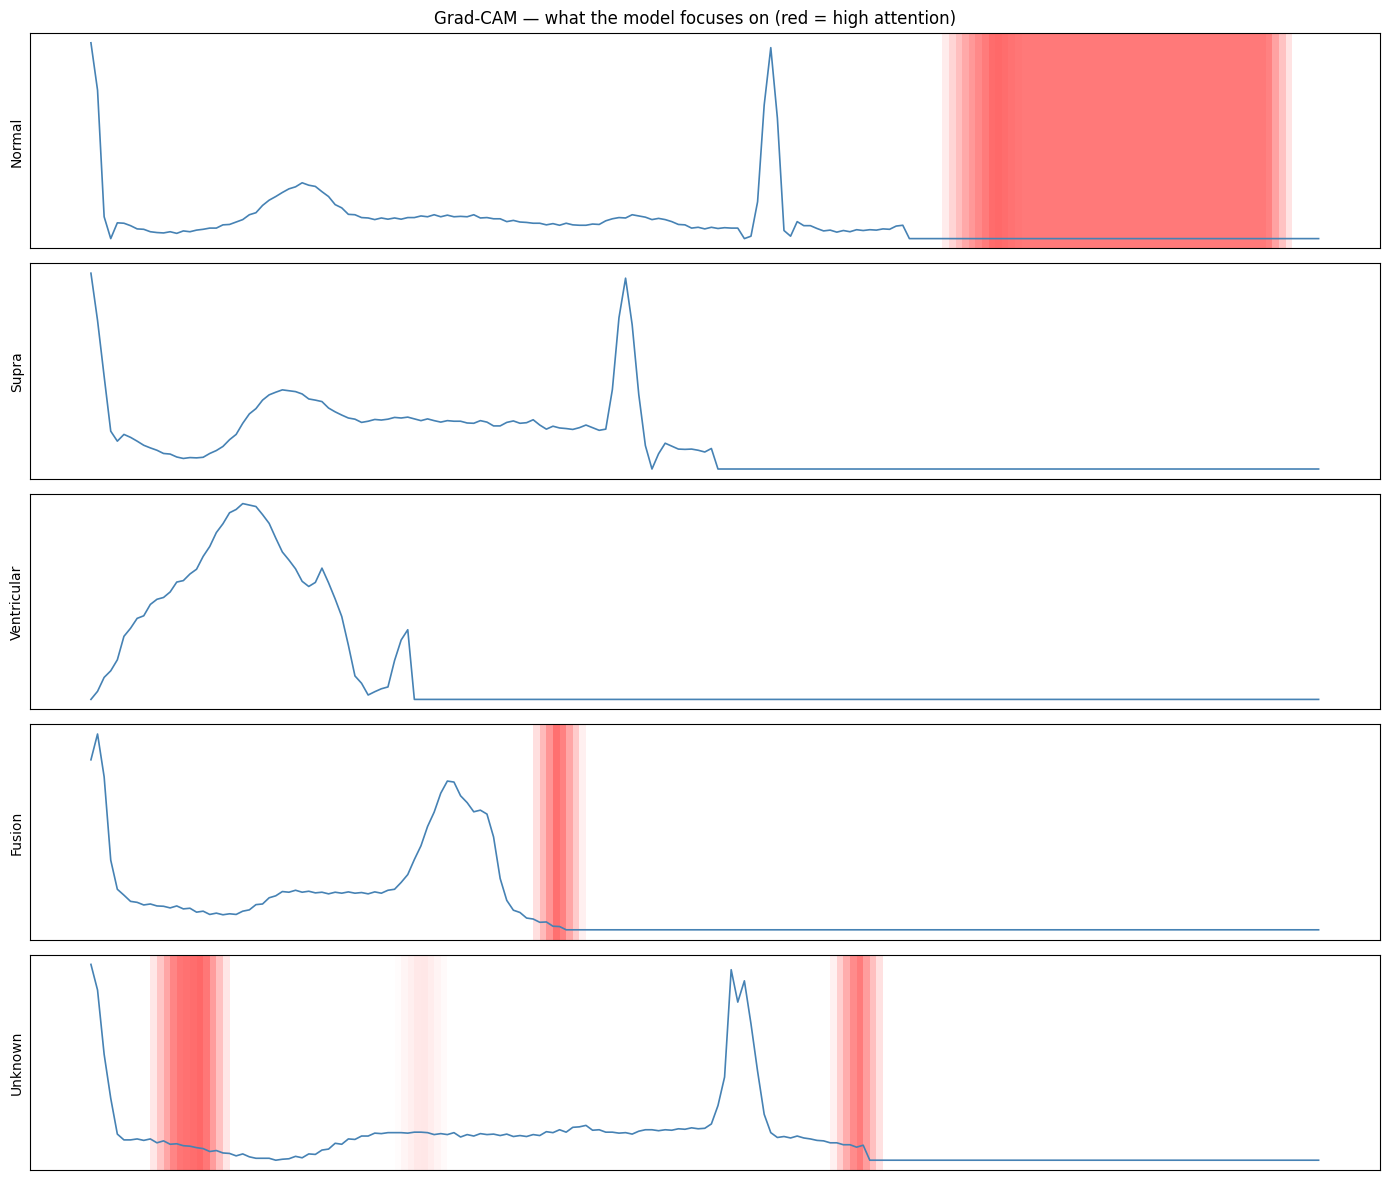

Saved gradcam_visualization.png


In [71]:
import torch.nn.functional as F

# Attach Grad-CAM to the last conv layer
gradcam = GradCAM1D(cnn_final, cnn_final.conv_block3[0])

fig, axes = plt.subplots(5, 1, figsize=(14, 12))

for cls in range(5):
    # Get one real sample of this class
    sample = test_df[test_df['label'] == cls].iloc[0, :187].values
    x = torch.tensor(sample, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

    # Compute Grad-CAM
    cam = gradcam.compute(x, class_idx=cls)

    # Upsample CAM to match signal length (187)
    cam_upsampled = np.interp(
        np.linspace(0, len(cam)-1, 187),
        np.arange(len(cam)),
        cam
    )

    # Plot signal
    ax = axes[cls]
    ax.plot(sample, color='steelblue', linewidth=1.2, label='ECG signal')

    # Overlay heatmap
    for i in range(186):
        ax.axvspan(i, i+1, alpha=cam_upsampled[i] * 0.6,
                  color='red', linewidth=0)

    ax.set_ylabel(class_names[cls], fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('Grad-CAM — what the model focuses on (red = high attention)',
             fontsize=12)
plt.tight_layout()
plt.savefig('gradcam_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved gradcam_visualization.png")

In [72]:
torch.save(cnn_final.state_dict(), 'ecg_cnn_final.pth')
print("Model saved")

Model saved


In [77]:
readme = """# ECG Heartbeat Classification with Deep Learning

Classifying cardiac arrhythmias from ECG signals using the [MIT-BIH dataset](https://www.kaggle.com/datasets/shayanfazeli/heartbeat).

## Results

| Model | Macro F1 |
|---|---|
| Random Forest (baseline) | 0.86 |
| 1D CNN + class weights | 0.90 |
| CNN + aggressive SMOTE | 0.83 |
| CNN + tuned SMOTE + Focal Loss | 0.93 |

Experiment tracking: [View on Weights & Biases](YOUR_WANDB_URL)

## Key Findings

- 1D CNN outperformed BiLSTM (macro F1: 0.90 vs 0.69) because ECG heartbeats
  are short sequences where local morphological features matter more than
  long-range dependencies
- Class weights alone outperformed aggressive SMOTE oversampling
- Tuned SMOTE (8k target) + Focal Loss achieved best results, improving
  Fusion F1 from 0.68 (baseline) to 0.84 — a 24% relative improvement
  on the hardest class

## What the model learned — Grad-CAM

![Grad-CAM](gradcam_visualization.png)

Red regions show where the model focuses its attention for each class.
The model correctly learns to focus on the QRS complex and T wave regions.

## Tech Stack

- PyTorch — model training
- Scikit-learn — baseline and evaluation
- imbalanced-learn — SMOTE oversampling
- Weights & Biases — experiment tracking

## Skills demonstrated

1D CNN, Focal Loss, SMOTE, Imbalanced Classification,
Grad-CAM Explainability, Experiment Tracking, PyTorch
"""

with open('README.md', 'w') as f:
    f.write(readme)

print("README.md saved")

README.md saved


In [78]:
from google.colab import files
files.download('README.md')
files.download('gradcam_visualization.png')
files.download('ecg_cnn_final.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>